
AND Gate
Epoch 1 Weights: [0. 0.] Bias: -0.1
Epoch 1 Weights: [0.1 0.1] Bias: 0.0
Epoch 2 Weights: [0.1 0.1] Bias: -0.1
Epoch 2 Weights: [0.1 0. ] Bias: -0.2
Epoch 2 Weights: [0.2 0.1] Bias: -0.1
Epoch 3 Weights: [0.2 0. ] Bias: -0.2
Epoch 3 Weights: [0.1 0. ] Bias: -0.30000000000000004
Epoch 3 Weights: [0.2 0.1] Bias: -0.20000000000000004

Converged at epoch 4

Final weights: [0.2 0.1]
Final bias: -0.20000000000000004


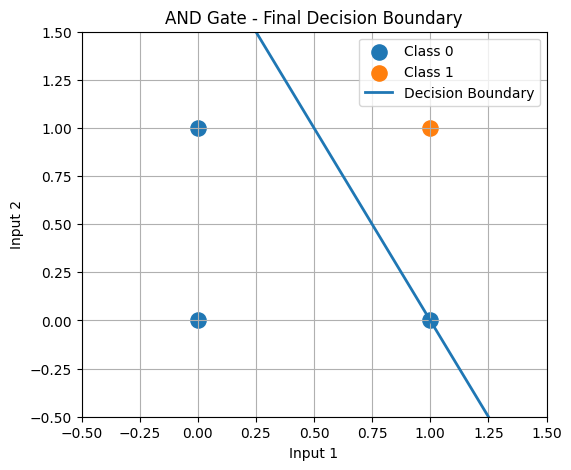


OR Gate
Epoch 1 Weights: [0. 0.] Bias: -0.1
Epoch 1 Weights: [0.  0.1] Bias: 0.0
Epoch 2 Weights: [0.  0.1] Bias: -0.1
Epoch 2 Weights: [0.1 0.1] Bias: 0.0
Epoch 3 Weights: [0.1 0.1] Bias: -0.1

Converged at epoch 4

Final weights: [0.1 0.1]
Final bias: -0.1


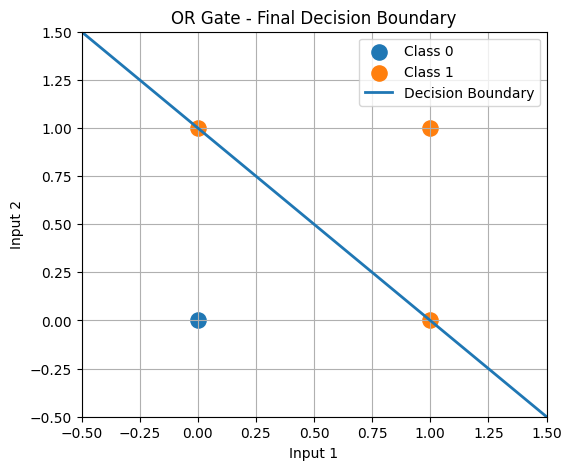


NOT Gate
Epoch 1 Weights: [-0.1] Bias: -0.1
Epoch 2 Weights: [-0.1] Bias: 0.0

Converged at epoch 3

Final weights: [-0.1]
Final bias: 0.0


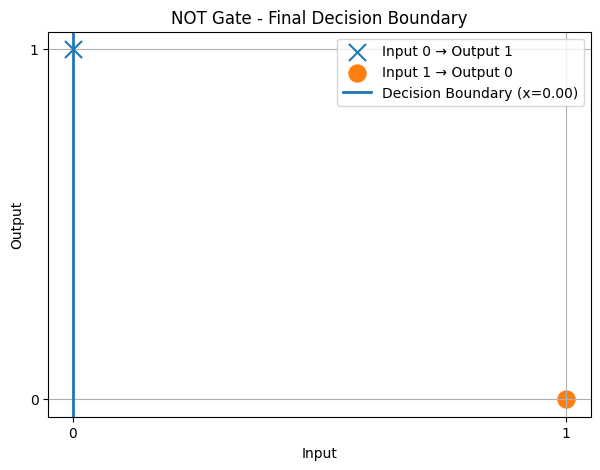


XOR Gate
Epoch 1 Weights: [0. 0.] Bias: -0.1
Epoch 1 Weights: [0.  0.1] Bias: 0.0
Epoch 1 Weights: [-0.1  0. ] Bias: -0.1
Epoch 2 Weights: [-0.1  0.1] Bias: 0.0
Epoch 2 Weights: [0.  0.1] Bias: 0.1
Epoch 2 Weights: [-0.1  0. ] Bias: 0.0
Epoch 3 Weights: [-0.1  0. ] Bias: -0.1
Epoch 3 Weights: [-0.1  0.1] Bias: 0.0
Epoch 3 Weights: [0.  0.1] Bias: 0.1
Epoch 3 Weights: [-0.1  0. ] Bias: 0.0
Epoch 4 Weights: [-0.1  0. ] Bias: -0.1
Epoch 4 Weights: [-0.1  0.1] Bias: 0.0
Epoch 4 Weights: [0.  0.1] Bias: 0.1
Epoch 4 Weights: [-0.1  0. ] Bias: 0.0
Epoch 5 Weights: [-0.1  0. ] Bias: -0.1
Epoch 5 Weights: [-0.1  0.1] Bias: 0.0
Epoch 5 Weights: [0.  0.1] Bias: 0.1
Epoch 5 Weights: [-0.1  0. ] Bias: 0.0
Epoch 6 Weights: [-0.1  0. ] Bias: -0.1
Epoch 6 Weights: [-0.1  0.1] Bias: 0.0
Epoch 6 Weights: [0.  0.1] Bias: 0.1
Epoch 6 Weights: [-0.1  0. ] Bias: 0.0
Epoch 7 Weights: [-0.1  0. ] Bias: -0.1
Epoch 7 Weights: [-0.1  0.1] Bias: 0.0
Epoch 7 Weights: [0.  0.1] Bias: 0.1
Epoch 7 Weights: [-0.1  0.

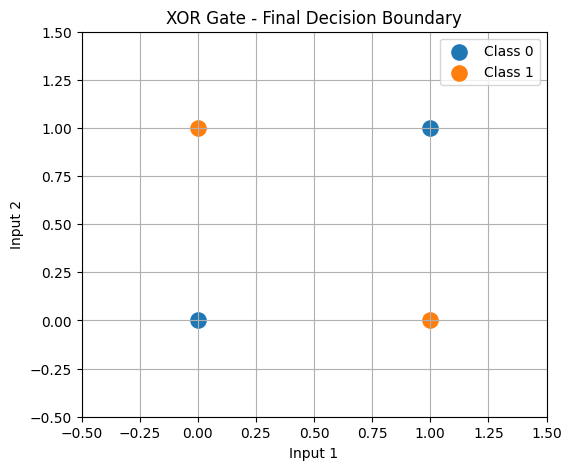


DONE!
Created:
Perceptron_Gate_Plots.zip


In [ ]:
# ============================================================
# SINGLE LAYER PERCEPTRON FOR LOGICAL GATES
# AND, OR, NOT, XOR
#
# Implemented from scratch
# Final Decision Boundary Visualization
# ============================================================


import numpy as np
import matplotlib.pyplot as plt
import os
import shutil



# ------------------------------------------------------------
# Create folder
# ------------------------------------------------------------

folder = "Perceptron_Gate_Plots"

os.makedirs(folder, exist_ok=True)



# ------------------------------------------------------------
# Perceptron Implementation
# ------------------------------------------------------------

class Perceptron:


    def __init__(self, learning_rate=0.1, epochs=20):

        self.lr = learning_rate
        self.epochs = epochs

        self.weights = None
        self.bias = None



    def step(self,z):

        return 1 if z >= 0 else 0



    def predict(self,x):

        z = np.dot(x,self.weights)+self.bias

        return self.step(z)



    def fit(self,X,y,name):


        self.weights = np.zeros(X.shape[1])

        self.bias = 0


        print("\n==============================")
        print(name,"Gate")
        print("==============================")


        for epoch in range(self.epochs):

            errors = 0


            for xi,target in zip(X,y):


                prediction = self.predict(xi)

                error = target-prediction



                if error != 0:


                    self.weights += (
                        self.lr *
                        error *
                        xi
                    )


                    self.bias += (
                        self.lr *
                        error
                    )


                    errors += 1


                    print(
                        f"Epoch {epoch+1}",
                        "Weights:",
                        self.weights,
                        "Bias:",
                        self.bias
                    )



            if errors == 0:

                print(
                    "\nConverged at epoch",
                    epoch+1
                )

                break



        print("\nFinal weights:",self.weights)

        print("Final bias:",self.bias)





# ------------------------------------------------------------
# 2D Decision Boundary Plot
# ------------------------------------------------------------

def plot_boundary(model,X,y,name):


    plt.figure(figsize=(6,5))


    for label in np.unique(y):

        plt.scatter(
            X[y==label,0],
            X[y==label,1],
            s=120,
            label=f"Class {label}"
        )



    w=model.weights
    b=model.bias



    if w[1]!=0:


        x=np.linspace(-0.5,1.5,100)

        y_line=-(w[0]*x+b)/w[1]


        plt.plot(
            x,
            y_line,
            linewidth=2,
            label="Decision Boundary"
        )



    plt.xlabel("Input 1")

    plt.ylabel("Input 2")

    plt.title(
        name+" Gate - Final Decision Boundary"
    )


    plt.xlim(-0.5,1.5)

    plt.ylim(-0.5,1.5)

    plt.grid()

    plt.legend()



    plt.savefig(
        f"{folder}/{name}_boundary.png",
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()





# ------------------------------------------------------------
# NOT Gate Plot
# ------------------------------------------------------------

def plot_not_boundary(model,X,y):


    plt.figure(figsize=(7,5))


    plt.scatter(
        X[y==1],
        y[y==1],
        marker="x",
        s=150,
        label="Input 0 → Output 1"
    )


    plt.scatter(
        X[y==0],
        y[y==0],
        marker="o",
        s=150,
        label="Input 1 → Output 0"
    )



    w=model.weights[0]

    b=model.bias


    boundary=-b/w



    plt.axvline(
        boundary,
        linewidth=2,
        label=f"Decision Boundary (x={boundary:.2f})"
    )



    plt.xlabel("Input")

    plt.ylabel("Output")


    plt.title(
        "NOT Gate - Final Decision Boundary"
    )


    plt.xticks([0,1])

    plt.yticks([0,1])


    plt.grid()

    plt.legend()



    plt.savefig(
        f"{folder}/NOT_boundary.png",
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()





# ============================================================
# AND Gate
# ============================================================


X_AND=np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])


y_AND=np.array([
    0,0,0,1
])


and_model=Perceptron()

and_model.fit(
    X_AND,
    y_AND,
    "AND"
)


plot_boundary(
    and_model,
    X_AND,
    y_AND,
    "AND"
)





# ============================================================
# OR Gate
# ============================================================


X_OR=np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])


y_OR=np.array([
    0,1,1,1
])


or_model=Perceptron()


or_model.fit(
    X_OR,
    y_OR,
    "OR"
)


plot_boundary(
    or_model,
    X_OR,
    y_OR,
    "OR"
)





# ============================================================
# NOT Gate
# ============================================================


X_NOT=np.array([
    [0],
    [1]
])


y_NOT=np.array([
    1,
    0
])


not_model=Perceptron()


not_model.fit(
    X_NOT,
    y_NOT,
    "NOT"
)


plot_not_boundary(
    not_model,
    X_NOT,
    y_NOT
)





# ============================================================
# XOR Gate
# ============================================================


X_XOR=np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])


y_XOR=np.array([
    0,1,1,0
])


xor_model=Perceptron(
    epochs=20
)


xor_model.fit(
    X_XOR,
    y_XOR,
    "XOR"
)


plot_boundary(
    xor_model,
    X_XOR,
    y_XOR,
    "XOR"
)





# ============================================================
# Create ZIP file
# ============================================================


shutil.make_archive(
    "Perceptron_Gate_Plots",
    "zip",
    folder
)


print("\n================================")
print("DONE!")
print("Created:")
print("Perceptron_Gate_Plots.zip")
print("================================")